In [1]:
import pandas as pd
import numpy as np

# Reproducible results
np.random.seed(42)

n = 300

# Employee IDs
employee_id = [f"EMP{i:03d}" for i in range(1, n + 1)]

# Departments
departments = np.random.choice(
    ["IT", "HR", "Finance", "Marketing", "Operations"],
    size=n
)

# Training status
training_status = np.random.choice(
    ["Trained", "Untrained"],
    size=n,
    p=[0.70, 0.30]
)

# Training duration
training_duration = np.where(
    training_status == "Trained",
    np.random.randint(5, 31, size=n),
    0
)

# Course type
course_type = np.where(
    training_status == "Trained",
    np.random.choice(
        ["Technical", "Leadership", "Communication", "Management"],
        size=n
    ),
    "None"
)

# Attendance percentage
training_attendance = np.where(
    training_status == "Trained",
    np.random.randint(60, 101, size=n),
    0
)

# Pre-training performance
pre_performance = np.random.randint(45, 86, size=n)

# Performance improvement
improvement = np.where(
    training_status == "Trained",
    (
        training_duration * 0.15
        + (training_attendance - 60) * 0.08
        + np.random.normal(2, 3, size=n)
    ),
    np.random.normal(1, 3, size=n)
)

# Post-training performance
post_performance = pre_performance + improvement

# Keep performance within 0–100
post_performance = np.clip(post_performance, 0, 100)

# Create dataframe
df = pd.DataFrame({
    "Employee_ID": employee_id,
    "Department": departments,
    "Training_Status": training_status,
    "Training_Duration": training_duration,
    "Course_Type": course_type,
    "Training_Attendance": training_attendance,
    "Pre_Training_Performance": np.round(pre_performance, 2),
    "Post_Training_Performance": np.round(post_performance, 2)
})

# Display dataset
print("Dataset created successfully!")
print("Shape:", df.shape)

display(df.head(10))

Dataset created successfully!
Shape: (300, 8)


,Employee_ID,Department,Training_Status,Training_Duration,Course_Type,Training_Attendance,Pre_Training_Performance,Post_Training_Performance
0,EMP001,Marketing,Untrained,0,None,0,55,57.97
1,EMP002,Operations,Trained,12,Leadership,82,85,86.32
2,EMP003,Finance,Trained,11,Management,87,47,54.26
3,EMP004,Operations,Trained,30,Management,91,72,79.72
4,EMP005,Operations,Untrained,0,None,0,73,74.15
5,EMP006,HR,Trained,6,Management,88,53,57.32
6,EMP007,Finance,Trained,26,Communication,67,47,57.61
7,EMP008,Finance,Trained,26,Technical,60,69,77.17
8,EMP009,Finance,Trained,7,Technical,62,78,81.30
9,EMP010,Operations,Trained,22,Leadership,83,56,67.88


In [2]:
# Check dataset structure

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (300, 8)

Column names:
['Employee_ID', 'Department', 'Training_Status', 'Training_Duration', 'Course_Type', 'Training_Attendance', 'Pre_Training_Performance', 'Post_Training_Performance']

Data types:
Employee_ID                   object
Department                    object
Training_Status               object
Training_Duration              int64
Course_Type                   object
Training_Attendance            int64
Pre_Training_Performance       int64
Post_Training_Performance    float64
dtype: object

Missing values:
Employee_ID                  0
Department                   0
Training_Status              0
Training_Duration            0
Course_Type                  0
Training_Attendance          0
Pre_Training_Performance     0
Post_Training_Performance    0
dtype: int64

Duplicate rows:
0


In [3]:
print("Training Status:")
print(df["Training_Status"].value_counts())

print("\nDepartments:")
print(df["Department"].value_counts())

print("\nCourse Types:")
print(df["Course_Type"].value_counts())

print("\nTraining Duration range:")
print(df["Training_Duration"].min(), "to", df["Training_Duration"].max())

print("\nAttendance range:")
print(df["Training_Attendance"].min(), "to", df["Training_Attendance"].max())

print("\nPre-training performance range:")
print(
    df["Pre_Training_Performance"].min(),
    "to",
    df["Pre_Training_Performance"].max()
)

print("\nPost-training performance range:")
print(
    df["Post_Training_Performance"].min(),
    "to",
    df["Post_Training_Performance"].max()
)

Training Status:
Training_Status
Trained      218
Untrained     82
Name: count, dtype: int64

Departments:
Department
Marketing     74
IT            69
Finance       63
Operations    48
HR            46
Name: count, dtype: int64

Course Types:
Course_Type
None             82
Leadership       61
Communication    54
Technical        53
Management       50
Name: count, dtype: int64

Training Duration range:
0 to 30

Attendance range:
0 to 100

Pre-training performance range:
45 to 85

Post-training performance range:
45.37 to 100.0


In [4]:
# Calculate performance improvement

df["Performance_Improvement"] = (
    df["Post_Training_Performance"]
    - df["Pre_Training_Performance"]
)

print("Performance improvement calculated successfully!")

display(
    df[
        [
            "Employee_ID",
            "Training_Status",
            "Pre_Training_Performance",
            "Post_Training_Performance",
            "Performance_Improvement"
        ]
    ].head(10)
)

Performance improvement calculated successfully!


,Employee_ID,Training_Status,Pre_Training_Performance,Post_Training_Performance,Performance_Improvement
0,EMP001,Untrained,55,57.97,2.97
1,EMP002,Trained,85,86.32,1.32
2,EMP003,Trained,47,54.26,7.26
3,EMP004,Trained,72,79.72,7.72
4,EMP005,Untrained,73,74.15,1.15
5,EMP006,Trained,53,57.32,4.32
6,EMP007,Trained,47,57.61,10.61
7,EMP008,Trained,69,77.17,8.17
8,EMP009,Trained,78,81.30,3.30
9,EMP010,Trained,56,67.88,11.88


In [5]:
# Descriptive statistics

print("===== DESCRIPTIVE STATISTICS =====")

display(
    df[
        [
            "Training_Duration",
            "Training_Attendance",
            "Pre_Training_Performance",
            "Post_Training_Performance",
            "Performance_Improvement"
        ]
    ].describe().round(2)
)

===== DESCRIPTIVE STATISTICS =====


,Training_Duration,Training_Attendance,Pre_Training_Performance,Post_Training_Performance,Performance_Improvement
count,300.00,300.00,300.00,300.00,300.00
mean,12.71,58.12,65.51,70.28,4.77
std,10.30,36.99,11.59,12.52,4.07
min,0.00,0.00,45.00,45.37,-5.50
25%,0.00,0.00,56.00,59.98,1.74
50%,12.00,73.00,66.00,70.84,4.77
75%,21.00,85.00,76.00,80.19,7.55
max,30.00,100.00,85.00,100.00,16.15


In [6]:
# Compare trained and untrained employees

comparison = (
    df.groupby("Training_Status")
    .agg(
        Employees=("Employee_ID", "count"),
        Avg_Pre_Performance=("Pre_Training_Performance", "mean"),
        Avg_Post_Performance=("Post_Training_Performance", "mean"),
        Avg_Improvement=("Performance_Improvement", "mean")
    )
    .round(2)
)

display(comparison)

,Employees,Avg_Pre_Performance,Avg_Post_Performance,Avg_Improvement
Training_Status,,,,
Trained,218,65.65,71.73,6.08
Untrained,82,65.15,66.43,1.28


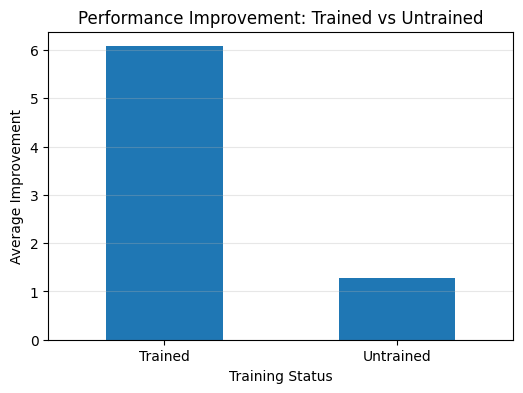

In [7]:
import matplotlib.pyplot as plt

avg_improvement = df.groupby("Training_Status")["Performance_Improvement"].mean()

avg_improvement.plot(kind="bar", figsize=(6,4))

plt.title("Performance Improvement: Trained vs Untrained")
plt.xlabel("Training Status")
plt.ylabel("Average Improvement")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

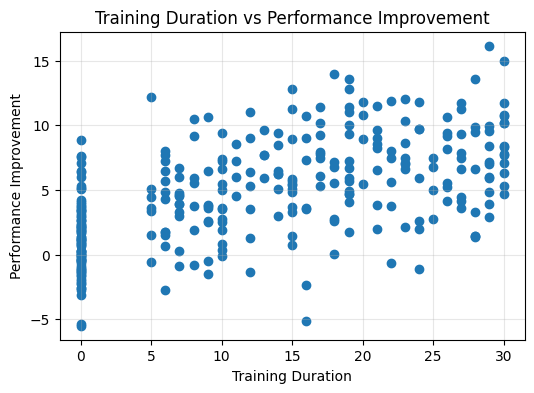

In [8]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["Training_Duration"],
    df["Performance_Improvement"]
)

plt.title("Training Duration vs Performance Improvement")
plt.xlabel("Training Duration")
plt.ylabel("Performance Improvement")
plt.grid(alpha=0.3)
plt.show()

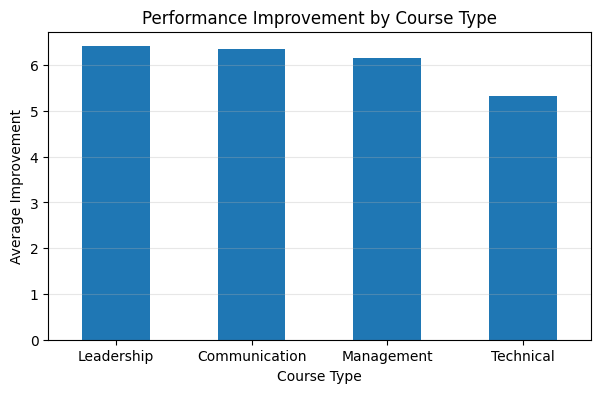

In [9]:
course_improvement = (
    df[df["Training_Status"] == "Trained"]
    .groupby("Course_Type")["Performance_Improvement"]
    .mean()
    .sort_values(ascending=False)
)

course_improvement.plot(kind="bar", figsize=(7,4))

plt.title("Performance Improvement by Course Type")
plt.xlabel("Course Type")
plt.ylabel("Average Improvement")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

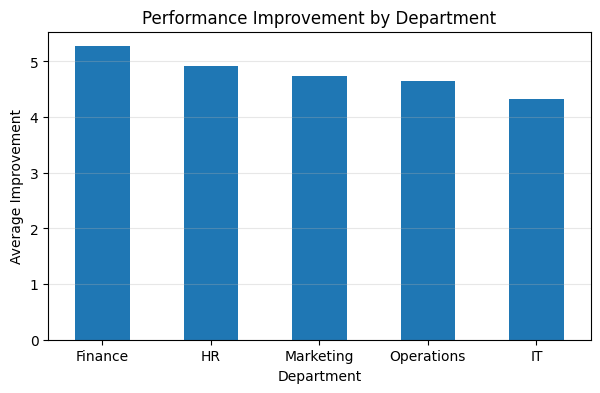

In [10]:
dept_improvement = (
    df.groupby("Department")["Performance_Improvement"]
    .mean()
    .sort_values(ascending=False)
)

dept_improvement.plot(kind="bar", figsize=(7,4))

plt.title("Performance Improvement by Department")
plt.xlabel("Department")
plt.ylabel("Average Improvement")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [11]:
# Check whether attendance and training duration are related to improvement

print("Average improvement by attendance level:")

df["Attendance_Group"] = pd.cut(
    df["Training_Attendance"],
    bins=[-1, 70, 85, 100],
    labels=["Low", "Medium", "High"]
)

display(
    df.groupby("Attendance_Group", observed=True)["Performance_Improvement"]
    .mean()
    .round(2)
)

Average improvement by attendance level:


,Performance_Improvement
Attendance_Group,
Low,2.73
Medium,6.04
High,7.01


In [12]:
print("Average improvement by training duration:")

df["Duration_Group"] = pd.cut(
    df["Training_Duration"],
    bins=[-1, 10, 20, 30],
    labels=["Short", "Medium", "Long"]
)

display(
    df.groupby("Duration_Group", observed=True)["Performance_Improvement"]
    .mean()
    .round(2)
)

Average improvement by training duration:


,Performance_Improvement
Duration_Group,
Short,2.43
Medium,6.49
Long,7.21


In [13]:
# Create target variable

df["Improved"] = (
    df["Performance_Improvement"] > 0
).astype(int)

print("Target created!")

print("\n0 = Not Improved")
print("1 = Improved")

print("\nTarget distribution:")
print(df["Improved"].value_counts())

Target created!

0 = Not Improved
1 = Improved

Target distribution:
Improved
1    259
0     41
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Select features
X = df[
    [
        "Department",
        "Training_Status",
        "Training_Duration",
        "Course_Type",
        "Training_Attendance",
        "Pre_Training_Performance"
    ]
].copy()

y = df["Improved"]

# Convert categorical columns
X = pd.get_dummies(
    X,
    columns=["Department", "Training_Status", "Course_Type"],
    drop_first=True
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

✅ Decision Tree trained!
Training samples: 240
Testing samples: 60


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = dt_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Improved", "Improved"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

Not Improved       0.12      0.12      0.12         8
    Improved       0.87      0.87      0.87        52

    accuracy                           0.77        60
   macro avg       0.50      0.50      0.50        60
weighted avg       0.77      0.77      0.77        60

Confusion Matrix:
[[ 1  7]
 [ 7 45]]


In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

,Feature,Importance
2,Pre_Training_Performance,0.378980
7,Training_Status_Untrained,0.277898
0,Training_Duration,0.147874
6,Department_Operations,0.088580
3,Department_HR,0.048994
5,Department_Marketing,0.033479
11,Course_Type_Technical,0.024195
1,Training_Attendance,0.000000
4,Department_IT,0.000000
8,Course_Type_Leadership,0.000000


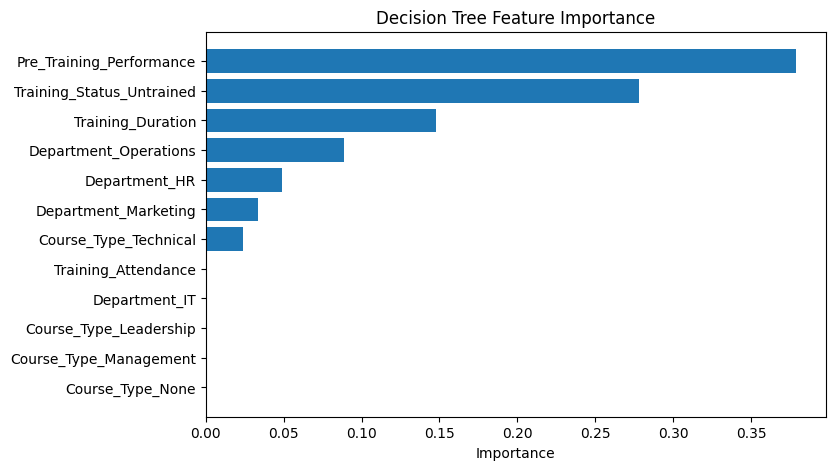

In [17]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [18]:
print("===== HR TRAINING EFFECTIVENESS — KEY INSIGHTS =====\n")

trained = df[df["Training_Status"] == "Trained"]
untrained = df[df["Training_Status"] == "Untrained"]

print(
    f"1. Trained employees had an average performance improvement of "
    f"{trained['Performance_Improvement'].mean():.2f}."
)

print(
    f"2. Untrained employees had an average performance improvement of "
    f"{untrained['Performance_Improvement'].mean():.2f}."
)

print(
    f"3. The average training duration among trained employees was "
    f"{trained['Training_Duration'].mean():.2f}."
)

print(
    f"4. The average training attendance among trained employees was "
    f"{trained['Training_Attendance'].mean():.2f}%."
)

best_course = course_improvement.idxmax()
print(
    f"5. {best_course} recorded the highest average improvement among "
    f"the training programmes."
)

best_department = dept_improvement.idxmax()
print(
    f"6. {best_department} recorded the highest average performance "
    f"improvement among departments."
)

print(
    f"7. {df['Improved'].sum()} out of {len(df)} employees were classified "
    f"as having improved performance."
)

===== HR TRAINING EFFECTIVENESS — KEY INSIGHTS =====

1. Trained employees had an average performance improvement of 6.08.
2. Untrained employees had an average performance improvement of 1.28.
3. The average training duration among trained employees was 17.49.
4. The average training attendance among trained employees was 79.98%.
5. Leadership recorded the highest average improvement among the training programmes.
6. Finance recorded the highest average performance improvement among departments.
7. 259 out of 300 employees were classified as having improved performance.


In [19]:
print("""
===== PRACTICAL ACTION PLAN =====

1. Monitor employee performance before and after training.
2. Improve attendance to increase training engagement.
3. Review training duration based on employee outcomes.
4. Compare different course types regularly.
5. Provide targeted training for departments needing improvement.
6. Use performance data to improve future training programmes.
7. Collect larger real-world datasets for better model reliability.
""")


===== PRACTICAL ACTION PLAN =====

1. Monitor employee performance before and after training.
2. Improve attendance to increase training engagement.
3. Review training duration based on employee outcomes.
4. Compare different course types regularly.
5. Provide targeted training for departments needing improvement.
6. Use performance data to improve future training programmes.
7. Collect larger real-world datasets for better model reliability.



In [20]:
# Save final dataset

df.to_csv(
    "hr_training_effectiveness_final.csv",
    index=False
)

print("✅ Final dataset saved!")
print("File: hr_training_effectiveness_final.csv")
print("Shape:", df.shape)

✅ Final dataset saved!
File: hr_training_effectiveness_final.csv
Shape: (300, 12)


In [21]:
check = pd.read_csv("hr_training_effectiveness_final.csv")

print("Rows:", check.shape[0])
print("Columns:", check.shape[1])

display(check.head())

Rows: 300
Columns: 12


,Employee_ID,Department,Training_Status,Training_Duration,Course_Type,Training_Attendance,Pre_Training_Performance,Post_Training_Performance,Performance_Improvement,Attendance_Group,Duration_Group,Improved
0,EMP001,Marketing,Untrained,0,NaN,0,55,57.97,2.97,Low,Short,1
1,EMP002,Operations,Trained,12,Leadership,82,85,86.32,1.32,Medium,Medium,1
2,EMP003,Finance,Trained,11,Management,87,47,54.26,7.26,High,Medium,1
3,EMP004,Operations,Trained,30,Management,91,72,79.72,7.72,High,Long,1
4,EMP005,Operations,Untrained,0,NaN,0,73,74.15,1.15,Low,Short,1
